# Training Code

In [1]:
from ultralytics import YOLO
import os
import torch

# Set CUDA_LAUNCH_BLOCKING for debugging (remove after confirming stability)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Define paths
main_dir = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11"
data_yaml = os.path.join(main_dir, "data.yaml")
results_dir = os.path.join(main_dir, "training_results")
pretrained_model = "yolo11n-seg.pt"  # Nano segmentation model

# Create results directory if it doesn’t exist
os.makedirs(results_dir, exist_ok=True)

# Check GPU memory availability
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"Device Name: {torch.cuda.get_device_name(0)}")
print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
print(f"Memory Reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")

# Load the pretrained YOLOv11 segmentation model
model = YOLO(pretrained_model)

# Train the model with optimized parameters
model.train(
    data=data_yaml,                  # Path to dataset configuration
    task="segment",                  # Task: segmentation
    epochs=100,                      # Maximum number of epochs
    batch=4,                         # Reduced batch size to avoid OOM
    imgsz=640,                       # Image size
    project=results_dir,             # Save all outputs here
    name="segment_exp",              # Experiment name
    exist_ok=True,                   # Overwrite if directory exists
    device=0,                        # Use GPU
    patience=10,                     # Early stopping after 10 epochs of no improvement
    save_period=10,                  # Save weights every 10 epochs
    verbose=True,                    # Detailed logs
    lr0=0.001,                       # Initial learning rate
    lrf=0.01,                        # Final learning rate factor
    weight_decay=0.0005,             # L2 regularization
    dropout=0.1,                     # Dropout for regularization
    augment=True,                    # Enable data augmentation
    mosaic=1.0,                      # Mosaic augmentation
    mixup=0.1,                       # Mixup augmentation
    hsv_h=0.015,                     # Hue augmentation
    hsv_s=0.7,                       # Saturation augmentation
    hsv_v=0.4,                       # Value augmentation
    degrees=10.0,                    # Rotation
    translate=0.1,                   # Translation
    scale=0.5,                       # Scaling
    shear=2.0,                       # Shearing
    fliplr=0.5,                      # Horizontal flip probability
    workers=4,                       # Reduced workers to lower memory usage
    cache=False,                     # Disable cache to ensure fresh data
    amp=False                        # Disable AMP to avoid potential CUDA errors
)

# Evaluate the model on the validation set
results = model.val(task="segment")

# Print segmentation metrics
print("Validation Results (Segmentation):")
print(f"mAP@50: {results.seg.map50:.4f}")
print(f"mAP@50:95: {results.seg.map:.4f}")

# Optional: Predict on test set and save results
test_results = model.predict(
    source=os.path.join(main_dir, "test", "images"),
    save=True,
    project=results_dir,
    name="segment_test",
    exist_ok=True,
    task="segment"
)

print("Training and evaluation completed! All results saved in:", results_dir)

GPU Available: True
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Memory Allocated: 0.00 MB
Memory Reserved: 0.00 MB
Ultralytics 8.3.97  Python-3.9.21 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: task=segment, mode=train, model=yolo11n-seg.pt, data=C:\Users\farza\Downloads\M.TECH.v31i.yolov11\data.yaml, epochs=100, time=None, patience=10, batch=4, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=4, project=C:\Users\farza\Downloads\M.TECH.v31i.yolov11\training_results, name=segment_exp, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.1, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, st

train: Scanning C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\labels.cache... 10032 images, 1 backgrounds, 0 corrupt: 100%|██████████| 10032/10032 [00:00<?, ?it/s]

train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.16153476afecd4e9fe096568093d2457.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.1e0e0da839eb9dba6f31d054b0fc1b6b.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.ab75aa6e6a0496e623a4fa208f39ac68.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.0604f65456e64601ade788709a8a04d0.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.593fae9972bf7aaedd47d4076682ef4f.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.770aca03c7df9d9adc3fd2afaec3c420.jpg: 1 duplicate labels removed
trai


val: Scanning C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\labels.cache... 729 images, 0 backgrounds, 0 corrupt: 100%|██████████| 729/729 [00:00<?, ?it/s]

val: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\images\Prickly-Sida_augmented_6_1_jpg.rf.3e92a3f9ac08203b9acbca7eec9a4649.jpg: 1 duplicate labels removed
val: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\images\Swinecress_augmented_4_3_jpg.rf.5cccca7f1c1a62f121d27942fc336147.jpg: 1 duplicate labels removed


...

                   all        729       1060      0.763      0.624      0.684      0.545      0.751      0.614      0.676      0.445

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


     11/100      1.73G     0.7935      2.176      1.479      1.296         27        640: 100%|██████████| 2508/2508 [13:58<00:00,  2.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 92/92 [00:24<00:00,  3.72it/s]


                   all        729       1060      0.766      0.662      0.713       0.57      0.764      0.656      0.705      0.466

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


     12/100      1.73G     0.7768      2.201       1.45      1.277         16        640:  11%|█         | 264/2508 [01:28<12:28,  3.00it/s]


KeyboardInterrupt: 

# Code to Resume Training

In [1]:
from ultralytics import YOLO
import os
import torch

# Set CUDA_LAUNCH_BLOCKING for debugging (optional, remove after confirming stability)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Define paths
main_dir = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11"
data_yaml = os.path.join(main_dir, "data.yaml")
results_dir = os.path.join(main_dir, "training_results")
pretrained_model = "yolo11n-seg.pt"  # Nano segmentation model
checkpoint_path = os.path.join(results_dir, "segment_exp", "weights", "last.pt")  # Path to last checkpoint

# Create results directory if it doesn’t exist
os.makedirs(results_dir, exist_ok=True)

# Check GPU availability and memory
if torch.cuda.is_available():
    print(f"GPU Available: True")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
    print(f"Memory Reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    device = 0  # Use GPU
else:
    print("GPU not available, switching to CPU.")
    device = "cpu"  # Use CPU

# Verify data.yaml exists
if not os.path.exists(data_yaml):
    raise FileNotFoundError(f"data.yaml not found at {data_yaml}. Please check the path.")

# Load the model: Resume from checkpoint if available, otherwise start fresh
try:
    if os.path.exists(checkpoint_path):
        print(f"Resuming training from checkpoint: {checkpoint_path}")
        model = YOLO(checkpoint_path)  # Load the last saved checkpoint
        resume_training = True
    else:
        print("Starting fresh training with pretrained model.")
        model = YOLO(pretrained_model)  # Load pretrained model
        resume_training = False
except Exception as e:
    raise RuntimeError(f"Failed to load model: {e}")

# Train the model with optimized parameters
try:
    model.train(
        data=data_yaml,                  # Path to dataset configuration
        task="segment",                  # Task: segmentation
        epochs=100,                      # Maximum number of epochs
        batch=4,                         # Reduced batch size to avoid OOM
        imgsz=640,                       # Image size
        project=results_dir,             # Save all outputs here
        name="segment_exp",              # Experiment name
        exist_ok=True,                   # Overwrite if directory exists
        device=device,                   # Use GPU or CPU based on availability
        patience=10,                     # Early stopping after 10 epochs of no improvement
        save_period=10,                  # Save weights every 10 epochs
        verbose=True,                    # Detailed logs
        lr0=0.001,                       # Initial learning rate
        lrf=0.01,                        # Final learning rate factor
        weight_decay=0.0005,             # L2 regularization
        dropout=0.1,                     # Dropout for regularization
        augment=True,                    # Enable data augmentation
        mosaic=1.0,                      # Mosaic augmentation
        mixup=0.1,                       # Mixup augmentation
        hsv_h=0.015,                     # Hue augmentation
        hsv_s=0.7,                       # Saturation augmentation
        hsv_v=0.4,                       # Value augmentation
        degrees=10.0,                    # Rotation
        translate=0.1,                   # Translation
        scale=0.5,                       # Scaling
        shear=2.0,                       # Shearing
        fliplr=0.5,                      # Horizontal flip probability
        workers=4,                       # Reduced workers to lower memory usage
        cache=False,                     # Disable cache to ensure fresh data
        amp=False,                       # Disable AMP to avoid potential CUDA errors
        resume=resume_training           # Resume if checkpoint exists, otherwise start fresh
    )
except Exception as e:
    raise RuntimeError(f"Training failed: {e}")

# Evaluate the model on the validation set
try:
    results = model.val(task="segment")
except Exception as e:
    print(f"Validation failed: {e}")
    results = None

# Print segmentation metrics if validation succeeded
if results:
    print("Validation Results (Segmentation):")
    print(f"mAP@50: {results.seg.map50:.4f}")
    print(f"mAP@50:95: {results.seg.map:.4f}")

# Optional: Predict on test set and save results
try:
    test_results = model.predict(
        source=os.path.join(main_dir, "test", "images"),
        save=True,
        project=results_dir,
        name="segment_test",
        exist_ok=True,
        task="segment"
    )
except Exception as e:
    print(f"Prediction failed: {e}")

print("Training and evaluation completed! All results saved in:", results_dir)

GPU Available: True
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Memory Allocated: 0.00 MB
Memory Reserved: 0.00 MB
Resuming training from checkpoint: C:\Users\farza\Downloads\M.TECH.v31i.yolov11\training_results\segment_exp\weights\last.pt
Ultralytics 8.3.97  Python-3.9.21 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: task=segment, mode=train, model=C:\Users\farza\Downloads\M.TECH.v31i.yolov11\training_results\segment_exp\weights\last.pt, data=C:\Users\farza\Downloads\M.TECH.v31i.yolov11\data.yaml, epochs=100, time=None, patience=10, batch=4, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=4, project=C:\Users\farza\Downloads\M.TECH.v31i.yolov11\training_results, name=segment_exp, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=C:\Users\farza\Downloads\M.TECH.v31i.yolov11\training_results\segment_exp\weigh

train: Scanning C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\labels.cache... 10032 images, 1 backgrounds, 0 corrupt: 100%|██████████| 10032/10032 [00:00<?, ?it/s]

train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.16153476afecd4e9fe096568093d2457.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.1e0e0da839eb9dba6f31d054b0fc1b6b.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.ab75aa6e6a0496e623a4fa208f39ac68.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.0604f65456e64601ade788709a8a04d0.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.593fae9972bf7aaedd47d4076682ef4f.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.770aca03c7df9d9adc3fd2afaec3c420.jpg: 1 duplicate labels removed
trai


val: Scanning C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\labels.cache... 729 images, 0 backgrounds, 0 corrupt: 100%|██████████| 729/729 [00:00<?, ?it/s]

val: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\images\Prickly-Sida_augmented_6_1_jpg.rf.3e92a3f9ac08203b9acbca7eec9a4649.jpg: 1 duplicate labels removed
val: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\images\Swinecress_augmented_4_3_jpg.rf.5cccca7f1c1a62f121d27942fc336147.jpg: 1 duplicate labels removed


...

WARNING  Model does not support 'augment=True', reverting to single-scale prediction.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  99%|█████████▉| 182/183 [00:26<00:00,  7.08it/s]

WARNING  Model does not support 'augment=True', reverting to single-scale prediction.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 183/183 [00:26<00:00,  6.90it/s]


                   all        729       1060      0.809      0.732      0.788      0.664      0.802      0.727      0.775      0.538
           Carpetweeds         33         61      0.763      0.528      0.677      0.531      0.835      0.581      0.718       0.43
                Cotton         46         60      0.962      0.842       0.93      0.855      0.962      0.843       0.93      0.794
             Crabgrass         43         62      0.783      0.641      0.714      0.622      0.783      0.642      0.725      0.436
               Eclipta         45         62       0.75       0.79      0.851      0.756      0.764      0.806      0.859       0.65
            Goosegrass         58         61       0.96      0.934      0.978      0.895       0.96      0.934      0.978      0.646
          Morningglory         44         96      0.608      0.583      0.619       0.46      0.617      0.594      0.624      0.412
              Nutsedge         50         61      0.863      0.726   

# Extended weed segmentation by generating a density map, dividing images into a 10x10 grid and calculating weed area per cell.


0: 640x640 5 Purslanes, 10.2ms
Speed: 2.2ms preprocess, 10.2ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 640)


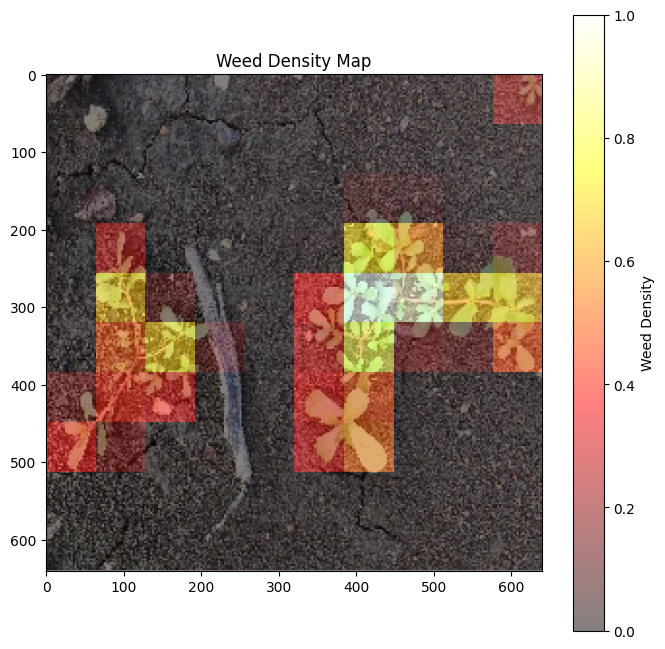

Max Density: 1.00
Average Density: 0.12
Number of High-Density Cells: 10
Overall Severity: High


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the YOLO model
model = YOLO("C:/Users/farza/Downloads/M.TECH.v31i.yolov11/training_results/segment_exp/weights/best.pt")  # Replace with the path to your trained model (e.g., best.pt)

# Load an image
image_path = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\novelty_test\images\Purslane_228_jpg.rf.c5a20e5a5feeea95cbc33bf04f5d733d.jpg"  # Replace with your test image path (e.g., from test folder)
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# Run prediction
results = model.predict(image, conf=0.25)  # Confidence threshold can be adjusted

# Get masks and class labels
masks = results[0].masks.data.cpu().numpy()  # Shape: (num_instances, height, width)
cls = results[0].boxes.cls.cpu().numpy()     # Class indices as a numpy array

# Filter masks to include only weeds (exclude cotton, class 1)
weed_mask_indices = np.where(cls != 1)[0]  # Indices where class is not cotton (class 1)

# Combine weed masks
if len(weed_mask_indices) > 0:
    weed_masks = masks[weed_mask_indices]  # Select only weed masks
    combined_weed_mask = np.max(weed_masks, axis=0)  # Combine all weed masks into one
else:
    # If no weeds are detected, create a zero mask
    combined_weed_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

# Define grid size for density map (e.g., 10x10 grid)
grid_size = 10
cell_height = image.shape[0] // grid_size
cell_width = image.shape[1] // grid_size

# Initialize density grid
density_grid = np.zeros((grid_size, grid_size))

# Calculate weed area in each grid cell
for i in range(grid_size):
    for j in range(grid_size):
        y_start = i * cell_height
        y_end = (i + 1) * cell_height
        x_start = j * cell_width
        x_end = (j + 1) * cell_width
        cell_mask = combined_weed_mask[y_start:y_end, x_start:x_end]
        density_grid[i, j] = cell_mask.sum()  # Sum of weed pixels in the cell

# Normalize density grid for visualization
density_grid = density_grid / density_grid.max() if density_grid.max() > 0 else density_grid

# Visualize the heatmap
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Show original image in RGB
plt.imshow(density_grid, cmap='hot', alpha=0.5, extent=[0, image.shape[1], image.shape[0], 0])
plt.colorbar(label='Weed Density')
plt.title("Weed Density Map")
plt.savefig("weed_density_map.png")  # Save the output
plt.show()

# Calculate statistics
max_density = density_grid.max()
avg_density = density_grid.mean()
high_density_threshold = 0.5  # Adjustable threshold
num_high_density_cells = np.sum(density_grid > high_density_threshold)

print(f"Max Density: {max_density:.2f}")
print(f"Average Density: {avg_density:.2f}")
print(f"Number of High-Density Cells: {num_high_density_cells}")

# Classify overall severity
if num_high_density_cells > 5:
    overall_severity = "High"
elif num_high_density_cells > 2:
    overall_severity = "Medium"
else:
    overall_severity = "Low"
print(f"Overall Severity: {overall_severity}")

# Combined Code


0: 640x640 1 Eclipta, 1 Waterhemp, 73.2ms
Speed: 7.0ms preprocess, 73.2ms inference, 7.5ms postprocess per image at shape (1, 3, 640, 640)


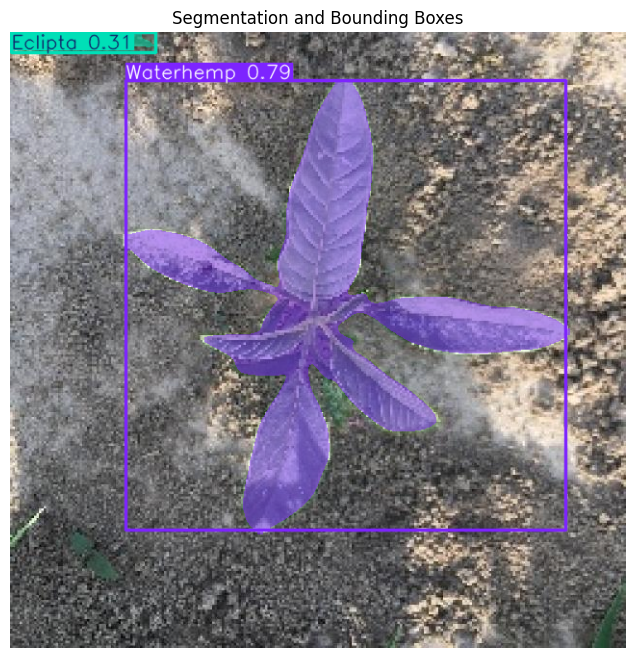

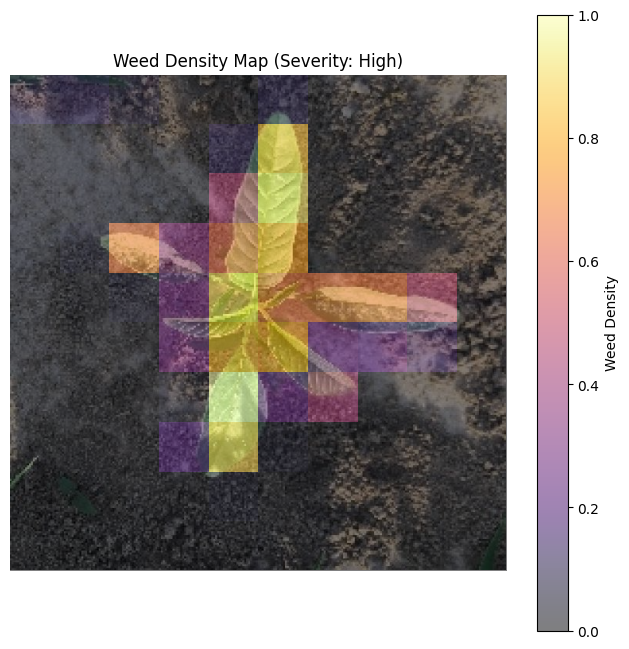

Predicted Weed Severity: High


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the trained YOLOv11n-seg model
model = YOLO("C:/Users/farza/Downloads/M.TECH.v31i.yolov11/training_results/segment_exp/weights/best.pt")  # Replace with your model path

# Load the test image
image_path = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\test\images\Waterhemp_46_jpg.rf.bd2074aea5aecaea0fe06573ae56cb24.jpg"  # Replace with your image path
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# Define class names from your data.yaml
class_names = ['Carpetweeds', 'Cotton', 'Crabgrass', 'Eclipta', 'Goosegrass', 'Morningglory', 
               'Nutsedge', 'PalmerAmaranth', 'Prickly-Sida', 'Purslane', 'Ragweed', 'Sicklepod', 
               'SpottedSpurge', 'SpurredAnoda', 'Swinecress', 'Waterhemp']

# Run prediction on the image
results = model.predict(image, conf=0.25)  # Confidence threshold of 0.25

# --- Step 1: Display Image with Segmentation and Bounding Boxes ---
annotated_image = results[0].plot()  # Adds boxes, masks, and labels
annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(annotated_image_rgb)
plt.title("Segmentation and Bounding Boxes")
plt.axis('off')
plt.show()

# --- Step 2: Generate and Display Weed Density Map with Severity ---
# Extract masks and class labels
masks = results[0].masks.data.cpu().numpy()  # Shape: (num_instances, height, width)
cls = results[0].boxes.cls.cpu().numpy()     # Class indices

# Filter out cotton (class 1) to keep only weed masks
weed_mask_indices = np.where(cls != 1)[0]  # Indices where class is not Cotton
if len(weed_mask_indices) > 0:
    weed_masks = masks[weed_mask_indices]
    combined_weed_mask = np.max(weed_masks, axis=0)  # Combine all weed masks
else:
    combined_weed_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)  # No weeds

# Define grid size for density map (10x10)
grid_size = 10
cell_height = image.shape[0] // grid_size
cell_width = image.shape[1] // grid_size

# Initialize density grid
density_grid = np.zeros((grid_size, grid_size))

# Calculate weed area in each grid cell
for i in range(grid_size):
    for j in range(grid_size):
        y_start = i * cell_height
        y_end = (i + 1) * cell_height
        x_start = j * cell_width
        x_end = (j + 1) * cell_width
        cell_mask = combined_weed_mask[y_start:y_end, x_start:x_end]
        density_grid[i, j] = cell_mask.sum()

# Normalize density grid (0.0 to 1.0 range)
if density_grid.max() > 0:
    density_grid = density_grid / density_grid.max()  # Scale to 1.0 when weeds are present
else:
    density_grid = density_grid  # Remains 0.0 when no weeds

# Calculate severity based on high-density cells
high_density_threshold = 0.5
num_high_density_cells = np.sum(density_grid > high_density_threshold)
if num_high_density_cells > 10:
    severity = "High"
elif num_high_density_cells > 5:
    severity = "Medium"
else:
    severity = "Low"

# Display the density map with fixed 0.0 to 1.0 range
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Original image in RGB
plt.imshow(density_grid, cmap='inferno', alpha=0.5, extent=[0, image.shape[1], image.shape[0], 0], 
           vmin=0.0, vmax=1.0)  # Force colormap range from 0.0 to 1.0
plt.colorbar(label='Weed Density')
plt.title(f"Weed Density Map (Severity: {severity})")
plt.axis('off')
plt.show()

# Print severity for confirmation
print(f"Predicted Weed Severity: {severity}")

# Automated Code

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# Define paths
test_folder = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\novelty_test\images" 
results_folder = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\novelty_test\results"
os.makedirs(results_folder, exist_ok=True)

# Load the trained YOLOv11n-seg model
model = YOLO("C:/Users/farza/Downloads/M.TECH.v31i.yolov11/training_results/segment_exp/weights/best.pt")

# Define class names from your data.yaml
class_names = ['Carpetweeds', 'Cotton', 'Crabgrass', 'Eclipta', 'Goosegrass', 'Morningglory', 
               'Nutsedge', 'PalmerAmaranth', 'Prickly-Sida', 'Purslane', 'Ragweed', 'Sicklepod', 
               'SpottedSpurge', 'SpurredAnoda', 'Swinecress', 'Waterhemp']

# Loop over all images in the test folder
for img_name in os.listdir(test_folder):
    if img_name.endswith(('.jpg', '.jpeg', '.png')):  # Process only image files
        image_path = os.path.join(test_folder, img_name)
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Could not load image at {image_path}")
            continue

        # Run prediction on the image
        results = model.predict(image, conf=0.25)  # Confidence threshold of 0.25

        # --- Step 1: Save Annotated Image with Segmentation and Bounding Boxes ---
        annotated_image = results[0].plot()  # Adds boxes, masks, and labels
        annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
        
        # Save the annotated image
        annotated_save_path = os.path.join(results_folder, f"{os.path.splitext(img_name)[0]}_annotated.png")
        plt.figure(figsize=(8, 8))
        plt.imshow(annotated_image_rgb)
        plt.title("Segmentation and Bounding Boxes")
        plt.axis('off')
        plt.savefig(annotated_save_path)
        plt.close()  # Close the figure to free memory

        # --- Step 2: Generate and Save Weed Density Map with Severity ---
        # Extract masks and class labels
        masks = results[0].masks.data.cpu().numpy()  # Shape: (num_instances, height, width)
        cls = results[0].boxes.cls.cpu().numpy()     # Class indices

        # Filter out cotton (class 1) to keep only weed masks
        weed_mask_indices = np.where(cls != 1)[0]  # Indices where class is not Cotton
        if len(weed_mask_indices) > 0:
            weed_masks = masks[weed_mask_indices]
            combined_weed_mask = np.max(weed_masks, axis=0)  # Combine all weed masks
        else:
            combined_weed_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)  # No weeds

        # Define grid size for density map (10x10)
        grid_size = 10
        cell_height = image.shape[0] // grid_size
        cell_width = image.shape[1] // grid_size

        # Initialize density grid
        density_grid = np.zeros((grid_size, grid_size))

        # Calculate weed area in each grid cell
        for i in range(grid_size):
            for j in range(grid_size):
                y_start = i * cell_height
                y_end = (i + 1) * cell_height
                x_start = j * cell_width
                x_end = (j + 1) * cell_width
                cell_mask = combined_weed_mask[y_start:y_end, x_start:x_end]
                density_grid[i, j] = cell_mask.sum()

        # Normalize density grid (0.0 to 1.0 range)
        if density_grid.max() > 0:
            density_grid = density_grid / density_grid.max()  # Scale to 1.0 when weeds are present
        else:
            density_grid = density_grid  # Remains 0.0 when no weeds

        # Calculate severity based on high-density cells
        high_density_threshold = 0.5
        num_high_density_cells = np.sum(density_grid > high_density_threshold)
        if num_high_density_cells > 10:
            severity = "High"
        elif num_high_density_cells > 5:
            severity = "Medium"
        else:
            severity = "Low"

        # Save the density map
        density_save_path = os.path.join(results_folder, f"{os.path.splitext(img_name)[0]}_density_map.png")
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Original image in RGB
        plt.imshow(density_grid, cmap='inferno', alpha=0.5, extent=[0, image.shape[1], image.shape[0], 0], 
                   vmin=0.0, vmax=1.0)  # Force colormap range from 0.0 to 1.0
        plt.colorbar(label='Weed Density')
        plt.title(f"Weed Density Map (Severity: {severity})")
        plt.axis('off')
        plt.savefig(density_save_path)
        plt.close()  # Close the figure to free memory

        # Print severity for confirmation
        print(f"Processed {img_name} - Predicted Weed Severity: {severity}")


0: 640x640 1 Carpetweeds, 51.5ms
Speed: 9.3ms preprocess, 51.5ms inference, 5.8ms postprocess per image at shape (1, 3, 640, 640)
Processed Carpetweeds_445_jpg.rf.3252176a7ad9952886c22a094a4be13a.jpg - Predicted Weed Severity: Medium

0: 640x640 1 Cotton, 61.7ms
Speed: 6.0ms preprocess, 61.7ms inference, 5.0ms postprocess per image at shape (1, 3, 640, 640)
Processed dsd-386-_iaip_jpg.rf.77f1ab6027530981da0a25e18707439d.jpg - Predicted Weed Severity: Low

0: 640x640 1 Nutsedge, 60.4ms
Speed: 6.5ms preprocess, 60.4ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 640)
Processed Nutsedge_175_jpg.rf.c51ac984801bfa626f7e6668b51ce28e.jpg - Predicted Weed Severity: High

0: 640x640 1 Nutsedge, 58.9ms
Speed: 5.7ms preprocess, 58.9ms inference, 5.5ms postprocess per image at shape (1, 3, 640, 640)
Processed Nutsedge_260_jpg.rf.8d82e43a77663c6376bacfb6c3910654.jpg - Predicted Weed Severity: Medium

0: 640x640 5 Purslanes, 132.2ms
Speed: 33.2ms preprocess, 132.2ms inference, 9.2ms 

# Metrics Evaluation for Validation Set

In [12]:
from ultralytics import YOLO
import os

# Define paths
MODEL_PATH = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\training_results\segment_exp\weights\best.pt"
DATASET_YAML = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\data.yaml"  # Path to your dataset YAML file
OUTPUT_DIR = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\Results Metrics Evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load the trained model
model = YOLO(MODEL_PATH)

# Validate the model
print("Starting validation...")
metrics = model.val(data=DATASET_YAML, imgsz=640, conf=0.25, iou=0.45, save_json=True, save_txt=True)

# Extract and print metrics
print("\n--- Detection Metrics ---")
print(f"Box mAP@0.5: {metrics.box.map50:.4f}")
print(f"Box mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Box Precision: {metrics.box.p.mean():.4f}")  # Mean precision across classes
print(f"Box Recall: {metrics.box.r.mean():.4f}")    # Mean recall across classes

print("\n--- Segmentation Metrics ---")
print(f"Mask mAP@0.5: {metrics.seg.map50:.4f}")
print(f"Mask mAP@0.5:0.95: {metrics.seg.map:.4f}")
print(f"Mask Precision: {metrics.seg.p.mean():.4f}")  # Mean precision across classes
print(f"Mask Recall: {metrics.seg.r.mean():.4f}")    # Mean recall across classes

# Optional: Save metrics to a file
with open(os.path.join(OUTPUT_DIR, 'metrics.txt'), 'w') as f:
    f.write("Detection Metrics\n")
    f.write(f"Box mAP@0.5: {metrics.box.map50:.4f}\n")
    f.write(f"Box mAP@0.5:0.95: {metrics.box.map:.4f}\n")
    f.write(f"Box Precision: {metrics.box.p.mean():.4f}\n")
    f.write(f"Box Recall: {metrics.box.r.mean():.4f}\n")
    f.write("\nSegmentation Metrics\n")
    f.write(f"Mask mAP@0.5: {metrics.seg.map50:.4f}\n")
    f.write(f"Mask mAP@0.5:0.95: {metrics.seg.map:.4f}\n")
    f.write(f"Mask Precision: {metrics.seg.p.mean():.4f}\n")
    f.write(f"Mask Recall: {metrics.seg.r.mean():.4f}\n")

print(f"\nResults saved to {OUTPUT_DIR}/metrics.txt")
print("Validation complete. Check the output directory for additional files (e.g., JSON, TXT).")

Starting validation...
Ultralytics 8.3.97  Python-3.9.21 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11n-seg summary (fused): 113 layers, 2,837,688 parameters, 0 gradients, 10.2 GFLOPs


val: Scanning C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\labels.cache... 729 images, 0 backgrounds, 0 corrupt: 100%|██████████| 729/729 [00:00<?, ?it/s]

val: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\images\Prickly-Sida_augmented_6_1_jpg.rf.3e92a3f9ac08203b9acbca7eec9a4649.jpg: 1 duplicate labels removed
val: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\valid\images\Swinecress_augmented_4_3_jpg.rf.5cccca7f1c1a62f121d27942fc336147.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 46/46 [00:33<00:00,  1.36it/s]


                   all        729       1060      0.804      0.741      0.803      0.706      0.798      0.736      0.795       0.58
           Carpetweeds         33         61      0.735      0.547      0.653      0.555      0.802      0.596       0.71       0.46
                Cotton         46         60      0.962       0.85      0.925       0.88      0.962       0.85      0.925      0.829
             Crabgrass         43         62      0.803      0.661      0.759      0.694      0.803      0.661      0.768        0.5
               Eclipta         45         62      0.756      0.798      0.857      0.783      0.771      0.814      0.865      0.681
            Goosegrass         58         61      0.957      0.934      0.964      0.901      0.957      0.934      0.964      0.665
          Morningglory         44         96      0.605      0.605      0.631      0.491      0.615      0.615      0.632      0.433
              Nutsedge         50         61       0.89      0.738   

# Metrics Evaluation for Test Set

In [13]:
from ultralytics import YOLO
import os

# Define paths
MODEL_PATH = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\training_results\segment_exp\weights\best.pt"
DATASET_YAML = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\data.yaml"  # Path to your dataset YAML file
OUTPUT_DIR = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\Results Metrics Evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load the trained model
model = YOLO(MODEL_PATH)

# Validate the model on the test set
print("Starting test set evaluation...")
metrics = model.val(data=DATASET_YAML, imgsz=640, conf=0.25, iou=0.45, split="test", save_json=True, save_txt=True)

# Extract and print metrics
print("\n--- Detection Metrics ---")
print(f"Box mAP@0.5: {metrics.box.map50:.4f}")
print(f"Box mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Box Precision: {metrics.box.p.mean():.4f}")  # Mean precision across classes
print(f"Box Recall: {metrics.box.r.mean():.4f}")    # Mean recall across classes

print("\n--- Segmentation Metrics ---")
print(f"Mask mAP@0.5: {metrics.seg.map50:.4f}")
print(f"Mask mAP@0.5:0.95: {metrics.seg.map:.4f}")
print(f"Mask Precision: {metrics.seg.p.mean():.4f}")  # Mean precision across classes
print(f"Mask Recall: {metrics.seg.r.mean():.4f}")    # Mean recall across classes

# Optional: Save metrics to a file
with open(os.path.join(OUTPUT_DIR, 'test_metrics.txt'), 'w') as f:
    f.write("Detection Metrics\n")
    f.write(f"Box mAP@0.5: {metrics.box.map50:.4f}\n")
    f.write(f"Box mAP@0.5:0.95: {metrics.box.map:.4f}\n")
    f.write(f"Box Precision: {metrics.box.p.mean():.4f}\n")
    f.write(f"Box Recall: {metrics.box.r.mean():.4f}\n")
    f.write("\nSegmentation Metrics\n")
    f.write(f"Mask mAP@0.5: {metrics.seg.map50:.4f}\n")
    f.write(f"Mask mAP@0.5:0.95: {metrics.seg.map:.4f}\n")
    f.write(f"Mask Precision: {metrics.seg.p.mean():.4f}\n")
    f.write(f"Mask Recall: {metrics.seg.r.mean():.4f}\n")

print(f"\nResults saved to {OUTPUT_DIR}/test_metrics.txt")
print("Test set evaluation complete. Check the output directory for additional files (e.g., JSON, TXT).")

Starting test set evaluation...
Ultralytics 8.3.97  Python-3.9.21 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11n-seg summary (fused): 113 layers, 2,837,688 parameters, 0 gradients, 10.2 GFLOPs


val: Scanning C:\Users\farza\Downloads\M.TECH.v31i.yolov11\test\labels... 345 images, 0 backgrounds, 0 corrupt: 100%|██████████| 345/345 [00:00<00:00, 409.40it/s]

val: New cache created: C:\Users\farza\Downloads\M.TECH.v31i.yolov11\test\labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:17<00:00,  1.27it/s]


                   all        345        516      0.794      0.761      0.819      0.716       0.79       0.76      0.817      0.611
           Carpetweeds         16         30      0.703      0.667      0.717      0.566      0.699      0.667      0.714      0.504
                Cotton         25         32      0.951      0.781      0.883      0.852      0.949      0.781      0.883      0.755
             Crabgrass         23         32      0.855      0.688      0.808      0.757      0.854      0.688      0.808      0.606
               Eclipta         28         31      0.819      0.968      0.961      0.907      0.817      0.968      0.961       0.82
            Goosegrass         26         30      0.796       0.91      0.936      0.869      0.796      0.912      0.936      0.669
          Morningglory         20         44      0.624      0.727      0.682      0.522      0.638       0.75      0.688      0.507
              Nutsedge         23         30      0.911        0.7   

# Enhanced Script for Evaluation Metrics (Test Set with Weed Density)

In [15]:
from ultralytics import YOLO
import os
import numpy as np
import cv2
from pathlib import Path

# Define paths
MODEL_PATH = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\training_results\segment_exp\weights\best.pt"
DATASET_YAML = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\data.yaml"
OUTPUT_DIR = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\Results Metrics Evaluation"
TEST_IMAGES_DIR = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11\test\images"  # Manual path to test images
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load the trained model
model = YOLO(MODEL_PATH)

# Validate the model on the test set
print("Starting test set evaluation...")
metrics = model.val(data=DATASET_YAML, imgsz=640, conf=0.25, iou=0.45, split="test", save_json=True, save_txt=True)

# Extract and print metrics
print("\n--- Detection Metrics ---")
print(f"Box mAP@0.5: {metrics.box.map50:.4f}")
print(f"Box mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Box Precision: {metrics.box.p.mean():.4f}")
print(f"Box Recall: {metrics.box.r.mean():.4f}")

print("\n--- Segmentation Metrics ---")
print(f"Mask mAP@0.5: {metrics.seg.map50:.4f}")
print(f"Mask mAP@0.5:0.95: {metrics.seg.map:.4f}")
print(f"Mask Precision: {metrics.seg.p.mean():.4f}")
print(f"Mask Recall: {metrics.seg.r.mean():.4f}")

# Compute weed density (custom addition)
COTTON_CLASS_ID = 1  # Adjust based on your class index (Cotton is 1 in 0-based indexing)
IMG_WIDTH, IMG_HEIGHT = 640, 640
densities = []

# Manually iterate over test images
test_image_paths = list(Path(TEST_IMAGES_DIR).glob("*.jpg"))  # Get all .jpg files in test directory
for img_path in test_image_paths:
    results = model.predict(img_path, conf=0.25)
    pred_mask = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)
    for r in results:
        masks = r.masks
        if masks:
            for i, mask in enumerate(masks.data):
                class_id = int(r.boxes.cls[i])
                mask_resized = cv2.resize(mask.cpu().numpy(), (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
                pred_mask = np.where(mask_resized > 0.5, class_id + 1, pred_mask)
    weed_mask = np.where((pred_mask != 0) & (pred_mask != COTTON_CLASS_ID + 1), 1, 0).astype(np.uint8)
    density_map, avg_d, max_d = compute_weed_density(weed_mask)
    densities.append({'avg': avg_d, 'max': max_d})

avg_density = np.mean([d['avg'] for d in densities]) if densities else 0.0
max_density = np.mean([d['max'] for d in densities]) if densities else 0.0
print("\n--- Weed Density ---")
print(f"Average Density: {avg_density:.4f}")
print(f"Max Density: {max_density:.4f}")

def compute_weed_density(pred_mask, grid_size=10):
    h, w = pred_mask.shape
    cell_h, cell_w = h // grid_size, w // grid_size
    density = np.zeros((grid_size, grid_size))
    for i in range(grid_size):
        for j in range(grid_size):
            cell = pred_mask[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            density[i, j] = cell.mean()
    return density, np.mean(density), np.max(density)

# Save metrics to a file
with open(os.path.join(OUTPUT_DIR, 'test_metrics.txt'), 'w') as f:
    f.write("Detection Metrics\n")
    f.write(f"Box mAP@0.5: {metrics.box.map50:.4f}\n")
    f.write(f"Box mAP@0.5:0.95: {metrics.box.map:.4f}\n")
    f.write(f"Box Precision: {metrics.box.p.mean():.4f}\n")
    f.write(f"Box Recall: {metrics.box.r.mean():.4f}\n")
    f.write("\nSegmentation Metrics\n")
    f.write(f"Mask mAP@0.5: {metrics.seg.map50:.4f}\n")
    f.write(f"Mask mAP@0.5:0.95: {metrics.seg.map:.4f}\n")
    f.write(f"Mask Precision: {metrics.seg.p.mean():.4f}\n")
    f.write(f"Mask Recall: {metrics.seg.r.mean():.4f}\n")
    f.write("\nWeed Density\n")
    f.write(f"Average Density: {avg_density:.4f}\n")
    f.write(f"Max Density: {max_density:.4f}\n")

print(f"\nResults saved to {OUTPUT_DIR}/test_metrics.txt")
print("Test set evaluation complete.")

Starting test set evaluation...
Ultralytics 8.3.97  Python-3.9.21 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11n-seg summary (fused): 113 layers, 2,837,688 parameters, 0 gradients, 10.2 GFLOPs


val: Scanning C:\Users\farza\Downloads\M.TECH.v31i.yolov11\test\labels.cache... 345 images, 0 backgrounds, 0 corrupt: 100%|██████████| 345/345 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:16<00:00,  1.36it/s]


                   all        345        516      0.794      0.761      0.819      0.716       0.79       0.76      0.817      0.611
           Carpetweeds         16         30      0.703      0.667      0.717      0.566      0.699      0.667      0.714      0.504
                Cotton         25         32      0.951      0.781      0.883      0.852      0.949      0.781      0.883      0.755
             Crabgrass         23         32      0.855      0.688      0.808      0.757      0.854      0.688      0.808      0.606
               Eclipta         28         31      0.819      0.968      0.961      0.907      0.817      0.968      0.961       0.82
            Goosegrass         26         30      0.796       0.91      0.936      0.869      0.796      0.912      0.936      0.669
          Morningglory         20         44      0.624      0.727      0.682      0.522      0.638       0.75      0.688      0.507
              Nutsedge         23         30      0.911        0.7   

# Training and Resume Code for YOLOv8n-seg

In [ ]:
from ultralytics import YOLO
import os
import torch

# Set CUDA_LAUNCH_BLOCKING for debugging (optional, remove after confirming stability)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Define paths
main_dir = r"C:\Users\farza\Downloads\M.TECH.v31i.yolov11"
data_yaml = os.path.join(main_dir, "data.yaml")
results_dir = os.path.join(main_dir, "YOLOv8")  # Separate folder for YOLOv8 results
pretrained_model = "yolov8n-seg.pt"  # Nano segmentation model for YOLOv8
checkpoint_path = os.path.join(results_dir, "yolov8n_training", "weights", "last.pt")  # Path to last checkpoint

# Create results directory if it doesn’t exist
os.makedirs(results_dir, exist_ok=True)

# Check GPU availability and memory
if torch.cuda.is_available():
    print(f"GPU Available: True")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
    print(f"Memory Reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    device = 0  # Use GPU (RTX 3050)
else:
    print("GPU not available, switching to CPU.")
    device = "cpu"  # Fallback to CPU

# Verify data.yaml exists
if not os.path.exists(data_yaml):
    raise FileNotFoundError(f"data.yaml not found at {data_yaml}. Please check the path.")

# Load the model: Resume from checkpoint if available, otherwise start fresh
try:
    if os.path.exists(checkpoint_path):
        print(f"Resuming training from checkpoint: {checkpoint_path}")
        model = YOLO(checkpoint_path)  # Load the last saved checkpoint
        resume_training = True
    else:
        print("Starting fresh training with pretrained model.")
        model = YOLO(pretrained_model)  # Load pretrained YOLOv8n-seg model
        resume_training = False
except Exception as e:
    raise RuntimeError(f"Failed to load model: {e}")

# Train the model with parameters matching YOLOv11
try:
    model.train(
        data=data_yaml,                  # Path to dataset configuration
        task="segment",                  # Task: segmentation
        epochs=100,                      # Maximum number of epochs
        batch=4,                         # Reduced batch size to avoid OOM
        imgsz=640,                       # Image size
        project=results_dir,             # Save all outputs here
        name="yolov8n_training",         # Experiment name
        exist_ok=True,                   # Overwrite if directory exists
        device=device,                   # Use GPU or CPU based on availability
        patience=10,                     # Early stopping after 10 epochs of no improvement
        save_period=10,                  # Save weights every 10 epochs
        verbose=True,                    # Detailed logs
        lr0=0.001,                       # Initial learning rate
        lrf=0.01,                        # Final learning rate factor
        weight_decay=0.0005,             # L2 regularization
        dropout=0.1,                     # Dropout for regularization
        augment=True,                    # Enable data augmentation
        mosaic=1.0,                      # Mosaic augmentation
        mixup=0.1,                       # Mixup augmentation
        hsv_h=0.015,                     # Hue augmentation
        hsv_s=0.7,                       # Saturation augmentation
        hsv_v=0.4,                       # Value augmentation
        degrees=10.0,                    # Rotation
        translate=0.1,                   # Translation
        scale=0.5,                       # Scaling
        shear=2.0,                       # Shearing
        fliplr=0.5,                      # Horizontal flip probability
        workers=4,                       # Reduced workers to lower memory usage
        cache=False,                     # Disable cache to ensure fresh data
        amp=False,                       # Disable AMP to avoid potential CUDA errors
        resume=resume_training           # Resume if checkpoint exists, otherwise start fresh
    )
except Exception as e:
    raise RuntimeError(f"Training failed: {e}")

# Evaluate the model on the validation set
try:
    results = model.val(task="segment", conf=0.25, iou=0.45)  # Match YOLOv11 validation settings
except Exception as e:
    print(f"Validation failed: {e}")
    results = None

# Print segmentation metrics if validation succeeded
if results:
    print("Validation Results (Segmentation):")
    print(f"mAP@50: {results.seg.map50:.4f}")
    print(f"mAP@50:95: {results.seg.map:.4f}")

# Optional: Predict on test set and save results
try:
    test_results = model.predict(
        source=os.path.join(main_dir, "test", "images"),
        save=True,
        project=results_dir,
        name="yolov8n_test",
        exist_ok=True,
        task="segment"
    )
except Exception as e:
    print(f"Prediction failed: {e}")

print("Training and evaluation completed! All results saved in:", results_dir)

GPU Available: True
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Memory Allocated: 0.00 MB
Memory Reserved: 0.00 MB
Starting fresh training with pretrained model.


100%|██████████| 6.74M/6.74M [00:01<00:00, 4.19MB/s]


New https://pypi.org/project/ultralytics/8.3.107 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.97  Python-3.9.21 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=C:\Users\farza\Downloads\M.TECH.v31i.yolov11\data.yaml, epochs=100, time=None, patience=10, batch=4, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=4, project=C:\Users\farza\Downloads\M.TECH.v31i.yolov11\YOLOv8, name=yolov8n_training, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.1, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualiz

train: Scanning C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\labels.cache... 10032 images, 1 backgrounds, 0 corrupt: 100%|██████████| 10032/10032 [00:00<?, ?it/s]

train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.16153476afecd4e9fe096568093d2457.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.1e0e0da839eb9dba6f31d054b0fc1b6b.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\Nutsedge_235_jpg.rf.ab75aa6e6a0496e623a4fa208f39ac68.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.0604f65456e64601ade788709a8a04d0.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.593fae9972bf7aaedd47d4076682ef4f.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\farza\Downloads\M.TECH.v31i.yolov11\train\images\SpottedSpurge_augmented_83_jpg.rf.770aca03c7df9d9adc3fd2afaec3c420.jpg: 1 duplicate labels removed
trai

...

     23/100      1.62G     0.7115      1.986      1.206      1.231         18        640: 100%|██████████| 2508/2508 [12:38<00:00,  3.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 92/92 [00:28<00:00,  3.22it/s]


                   all        729       1060      0.824      0.649      0.725      0.603      0.828      0.652      0.726      0.494

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


     24/100      1.62G     0.7064      1.958      1.177      1.227         26        640: 100%|██████████| 2508/2508 [12:49<00:00,  3.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 92/92 [00:24<00:00,  3.83it/s]


                   all        729       1060      0.785      0.663      0.728      0.602      0.795      0.646      0.715      0.489

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


     25/100      1.62G     0.6938      1.946      1.175      1.217         21        640:  13%|█▎        | 335/2508 [01:42<10:20,  3.50it/s]